# Sensor Data Converter End-to-End Test

This notebook generates synthetic 9-DoF IMU data, dual wheel encoder data, and vision position data.
It exports input CSV files, runs `SensorDataConverter`, saves converter outputs, and plots all signals.

## 1. Set Up Environment and Paths

Import libraries and define deterministic output paths for generated CSV files.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from Sensor_data_converter import SensorDataConverter

plt.style.use("seaborn-v0_8-whitegrid")

ROOT = Path.cwd()
SYNTH_DIR = ROOT / "csv" / "synthetic"
MEAS_DIR = ROOT / "csv" / "measurements"
SYNTH_DIR.mkdir(parents=True, exist_ok=True)
MEAS_DIR.mkdir(parents=True, exist_ok=True)

input_csv_path = SYNTH_DIR / "synthetic_sensor_inputs.csv"
converter_csv_path = SYNTH_DIR / "synthetic_converter_outputs.csv"
kalman_measurement_csv_path = MEAS_DIR / "sensor_measurements_synthetic_converter.csv"

print("Notebook root:", ROOT)
print("Input CSV:", input_csv_path)
print("Converter output CSV:", converter_csv_path)
print("Kalman measurement CSV:", kalman_measurement_csv_path)

Notebook root: /home/berko/Documents/Python Codes/BDRS/team-august/Kalman_filter_seperate_files
Input CSV: /home/berko/Documents/Python Codes/BDRS/team-august/Kalman_filter_seperate_files/csv/synthetic/synthetic_sensor_inputs.csv
Converter output CSV: /home/berko/Documents/Python Codes/BDRS/team-august/Kalman_filter_seperate_files/csv/synthetic/synthetic_converter_outputs.csv
Kalman measurement CSV: /home/berko/Documents/Python Codes/BDRS/team-august/Kalman_filter_seperate_files/csv/measurements/sensor_measurements_synthetic_converter.csv


## 2. Define Signal Model and Sampling (`dt`)

Create explicit `dt_s` with jitter so each sample can be passed to the converter exactly as in your pipeline.

In [2]:
rng = np.random.default_rng(42)

num_samples = 1200
nominal_dt = 0.01

dt_s = nominal_dt + rng.normal(0.0, 0.0015, size=num_samples)
dt_s = np.clip(dt_s, 0.005, 0.02)

t_s = np.cumsum(dt_s)
t_s = t_s - t_s[0]

print("samples:", num_samples)
print("dt range [s]:", float(dt_s.min()), "to", float(dt_s.max()))
print("total duration [s]:", float(t_s[-1]))

samples: 1200
dt range [s]: 0.005 to 0.014768280519051304
total duration [s]: 11.949987411377595


## 3. Generate Synthetic 9-DoF IMU Streams

Generate accelerometer, gyroscope, and magnetometer channels from a smooth motion profile with noise and small bias.

In [3]:
g = 9.80665

# True attitude profiles (rad)
yaw_true = 0.35 * np.sin(0.25 * t_s) + 0.04 * t_s
pitch_true = 0.08 * np.sin(0.45 * t_s)
roll_true = 0.05 * np.cos(0.33 * t_s)

# True rates (rad/s)
gx_true = np.gradient(roll_true, t_s)
gy_true = np.gradient(pitch_true, t_s)
gz_true = np.gradient(yaw_true, t_s)

# Forward speed profile and acceleration
v_forward_true = 0.7 + 0.2 * np.sin(0.18 * t_s) + 0.06 * np.cos(0.05 * t_s)
a_forward_true = np.gradient(v_forward_true, t_s)

# Body-frame accelerometer model with gravity contribution + sensor noise
ax = -g * np.sin(pitch_true) + a_forward_true + rng.normal(0.0, 0.08, num_samples)
ay = g * np.sin(roll_true) * np.cos(pitch_true) + rng.normal(0.0, 0.08, num_samples)
az = g * np.cos(roll_true) * np.cos(pitch_true) + rng.normal(0.0, 0.08, num_samples)

# Gyroscope with slight bias + noise
gx = gx_true + 0.003 + rng.normal(0.0, 0.004, num_samples)
gy = gy_true - 0.002 + rng.normal(0.0, 0.004, num_samples)
gz = gz_true + 0.001 + rng.normal(0.0, 0.004, num_samples)

# Magnetometer-like synthetic field (normalized style, with noise)
mx = np.cos(yaw_true) * np.cos(pitch_true) + rng.normal(0.0, 0.01, num_samples)
my = -np.sin(yaw_true) * np.cos(roll_true) + rng.normal(0.0, 0.01, num_samples)
mz = np.sin(pitch_true) + rng.normal(0.0, 0.01, num_samples)

## 4. Generate Encoder Rotation Channels (Radians)

Create two wheel encoder angular velocity streams in `rad/s` from differential-drive kinematics plus noise.

In [4]:
wheel_radius_m = 0.05
track_width_m = 0.30

yaw_rate_true = np.gradient(yaw_true, t_s)
v_left_true = v_forward_true - 0.5 * track_width_m * yaw_rate_true
v_right_true = v_forward_true + 0.5 * track_width_m * yaw_rate_true

encoder_left_radps = (v_left_true / wheel_radius_m) + rng.normal(0.0, 0.06, num_samples)
encoder_right_radps = (v_right_true / wheel_radius_m) + rng.normal(0.0, 0.06, num_samples)

# Optional quantization-like step
quant_step = 0.005
encoder_left_radps = np.round(encoder_left_radps / quant_step) * quant_step
encoder_right_radps = np.round(encoder_right_radps / quant_step) * quant_step

## 5. Generate Vision Position Channels (`px`, `py`, `pz`)

Generate a reference 3D path and noisy vision observations.

In [5]:
px_true = np.zeros(num_samples)
py_true = np.zeros(num_samples)
pz_true = np.zeros(num_samples)

for i in range(1, num_samples):
    ds = v_forward_true[i] * dt_s[i]
    px_true[i] = px_true[i - 1] + ds * np.cos(yaw_true[i]) * np.cos(pitch_true[i])
    py_true[i] = py_true[i - 1] + ds * np.sin(yaw_true[i]) * np.cos(pitch_true[i])
    pz_true[i] = pz_true[i - 1] + ds * np.sin(pitch_true[i])

vision_px_m = px_true + rng.normal(0.0, 0.03, num_samples)
vision_py_m = py_true + rng.normal(0.0, 0.03, num_samples)
vision_pz_m = pz_true + rng.normal(0.0, 0.02, num_samples)

## 6. Assemble Unified Test Dataset

Build one table containing `t_s`, `dt_s`, 9-DoF IMU channels, 2 encoder channels, and vision position channels.

In [6]:
raw_df = pd.DataFrame(
    {
        "t_s": t_s,
        "dt_s": dt_s,
        "ax_mps2": ax,
        "ay_mps2": ay,
        "az_mps2": az,
        "gx_radps": gx,
        "gy_radps": gy,
        "gz_radps": gz,
        "mx": mx,
        "my": my,
        "mz": mz,
        "encoder_left_radps": encoder_left_radps,
        "encoder_right_radps": encoder_right_radps,
        "vision_px_m": vision_px_m,
        "vision_py_m": vision_py_m,
        "vision_pz_m": vision_pz_m,
    }
)

print("raw_df shape:", raw_df.shape)
print("null count:", int(raw_df.isnull().sum().sum()))
print(raw_df.dtypes)

raw_df shape: (1200, 16)
null count: 0
t_s                    float64
dt_s                   float64
ax_mps2                float64
ay_mps2                float64
az_mps2                float64
gx_radps               float64
gy_radps               float64
gz_radps               float64
mx                     float64
my                     float64
mz                     float64
encoder_left_radps     float64
encoder_right_radps    float64
vision_px_m            float64
vision_py_m            float64
vision_pz_m            float64
dtype: object


## 7. Export Input CSV for Converter

Write synthetic inputs to CSV and preview schema/rows.

In [7]:
raw_df.to_csv(input_csv_path, index=False)
print(f"Saved input CSV: {input_csv_path}")
print(raw_df.head(3))

Saved input CSV: /home/berko/Documents/Python Codes/BDRS/team-august/Kalman_filter_seperate_files/csv/synthetic/synthetic_sensor_inputs.csv
        t_s      dt_s   ax_mps2   ay_mps2   az_mps2  gx_radps  gy_radps  \
0  0.000000  0.010457 -0.069804  0.454443  9.871854  0.003078  0.034900   
1  0.008440  0.008440 -0.005877  0.568542  9.987818  0.005125  0.033786   
2  0.019566  0.011126  0.062708  0.512612  9.683230  0.002836  0.037455   

   gz_radps        mx        my        mz  encoder_left_radps  \
0  0.131887  0.995217 -0.000424  0.000267              14.800   
1  0.131456  1.011590  0.005494 -0.005252              14.825   
2  0.130649  0.996069  0.005870 -0.004474              14.755   

   encoder_right_radps  vision_px_m  vision_py_m  vision_pz_m  
0               15.490     0.044041     0.023734     0.017743  
1               15.535     0.004622    -0.016888    -0.023451  
2               15.575    -0.021528     0.025061     0.001271  


## 8. Run Converter on Generated CSV

Use Python API to call `SensorDataConverter.update(...)` for every row.

In [7]:
converter = SensorDataConverter(wheel_radius_m=wheel_radius_m)

converter_rows = []
for row in raw_df.itertuples(index=False):
    sample = converter.update(
        dt_s=float(row.dt_s),
        vision_pos_xyz_m=(row.vision_px_m, row.vision_py_m, row.vision_pz_m),
        encoder_left=float(row.encoder_left_radps),
        encoder_right=float(row.encoder_right_radps),
        accel_xyz_mps2=(row.ax_mps2, row.ay_mps2, row.az_mps2),
        gyro_xyz_radps=(row.gx_radps, row.gy_radps, row.gz_radps),
        mag_xyz=(row.mx, row.my, row.mz),
        encoder_input_mode="angular_radps",
    )
    converter_rows.append(sample)

converter_df = pd.DataFrame(converter_rows)
print("converter_df shape:", converter_df.shape)
converter_df.head(3)

converter_df shape: (1200, 14)


,pos_x_s1,pos_y_s1,pos_z_s1,velocity_s1,angular_velocity_s1,yaw_s1,pitch_s1,pos_x_s2,pos_y_s2,pos_z_s2,velocity_s2,angular_velocity_s2,yaw_s2,pitch_s2
0,0.044041,0.023734,0.017743,0.75725,0.000000,0.000426,0.007063,0.007919,0.000011,0.000003,0.757244,0.131890,0.001379,0.000365
1,0.004622,-0.016888,-0.023451,0.75900,-0.693916,-0.005431,0.000587,0.014325,0.000027,0.000007,0.757243,0.131456,0.002489,0.000650
2,-0.021528,0.025061,0.001271,0.75825,-0.041565,-0.005894,-0.006467,0.022761,0.000060,0.000016,0.757236,0.130652,0.003942,0.001067


## 9. Load and Inspect Converter Output

Save converter outputs and build Kalman-style measurement CSV (`t_s` + 14 measurement columns).

In [8]:
converter_df.to_csv(converter_csv_path, index=False)

measurement_cols_14 = SensorDataConverter.VECTOR_ORDER_14
kalman_measurement_df = pd.concat(
    [raw_df[["t_s"]].reset_index(drop=True), converter_df[measurement_cols_14].reset_index(drop=True)],
    axis=1,
)

kalman_measurement_df.to_csv(kalman_measurement_csv_path, index=False)

print(f"Saved converter outputs: {converter_csv_path}")
print(f"Saved Kalman-style measurements: {kalman_measurement_csv_path}")
print("Rows aligned:", len(raw_df) == len(converter_df) == len(kalman_measurement_df))
print(kalman_measurement_df.head(3))

Saved converter outputs: /home/berko/Documents/Python Codes/BDRS/team-august/Kalman_filter_seperate_files/csv/synthetic/synthetic_converter_outputs.csv
Saved Kalman-style measurements: /home/berko/Documents/Python Codes/BDRS/team-august/Kalman_filter_seperate_files/csv/measurements/sensor_measurements_synthetic_converter.csv
Rows aligned: True
        t_s  pos_x_s1  pos_y_s1  pos_z_s1  velocity_s1  angular_velocity_s1  \
0  0.000000  0.044041  0.023734  0.017743      0.75725             0.000000   
1  0.008440  0.004622 -0.016888 -0.023451      0.75900            -0.693916   
2  0.019566 -0.021528  0.025061  0.001271      0.75825            -0.041565   

     yaw_s1  pitch_s1  pos_x_s2  pos_y_s2  pos_z_s2  velocity_s2  \
0  0.000426  0.007063  0.007919  0.000011  0.000003     0.757244   
1 -0.005431  0.000587  0.014325  0.000027  0.000007     0.757243   
2 -0.005894 -0.006467  0.022761  0.000060  0.000016     0.757236   

   angular_velocity_s2    yaw_s2  pitch_s2  
0             0.131

## 10. Plot Raw Inputs and Converter Outputs

Plot IMU, encoders, vision, converted signals, and trajectory comparison.

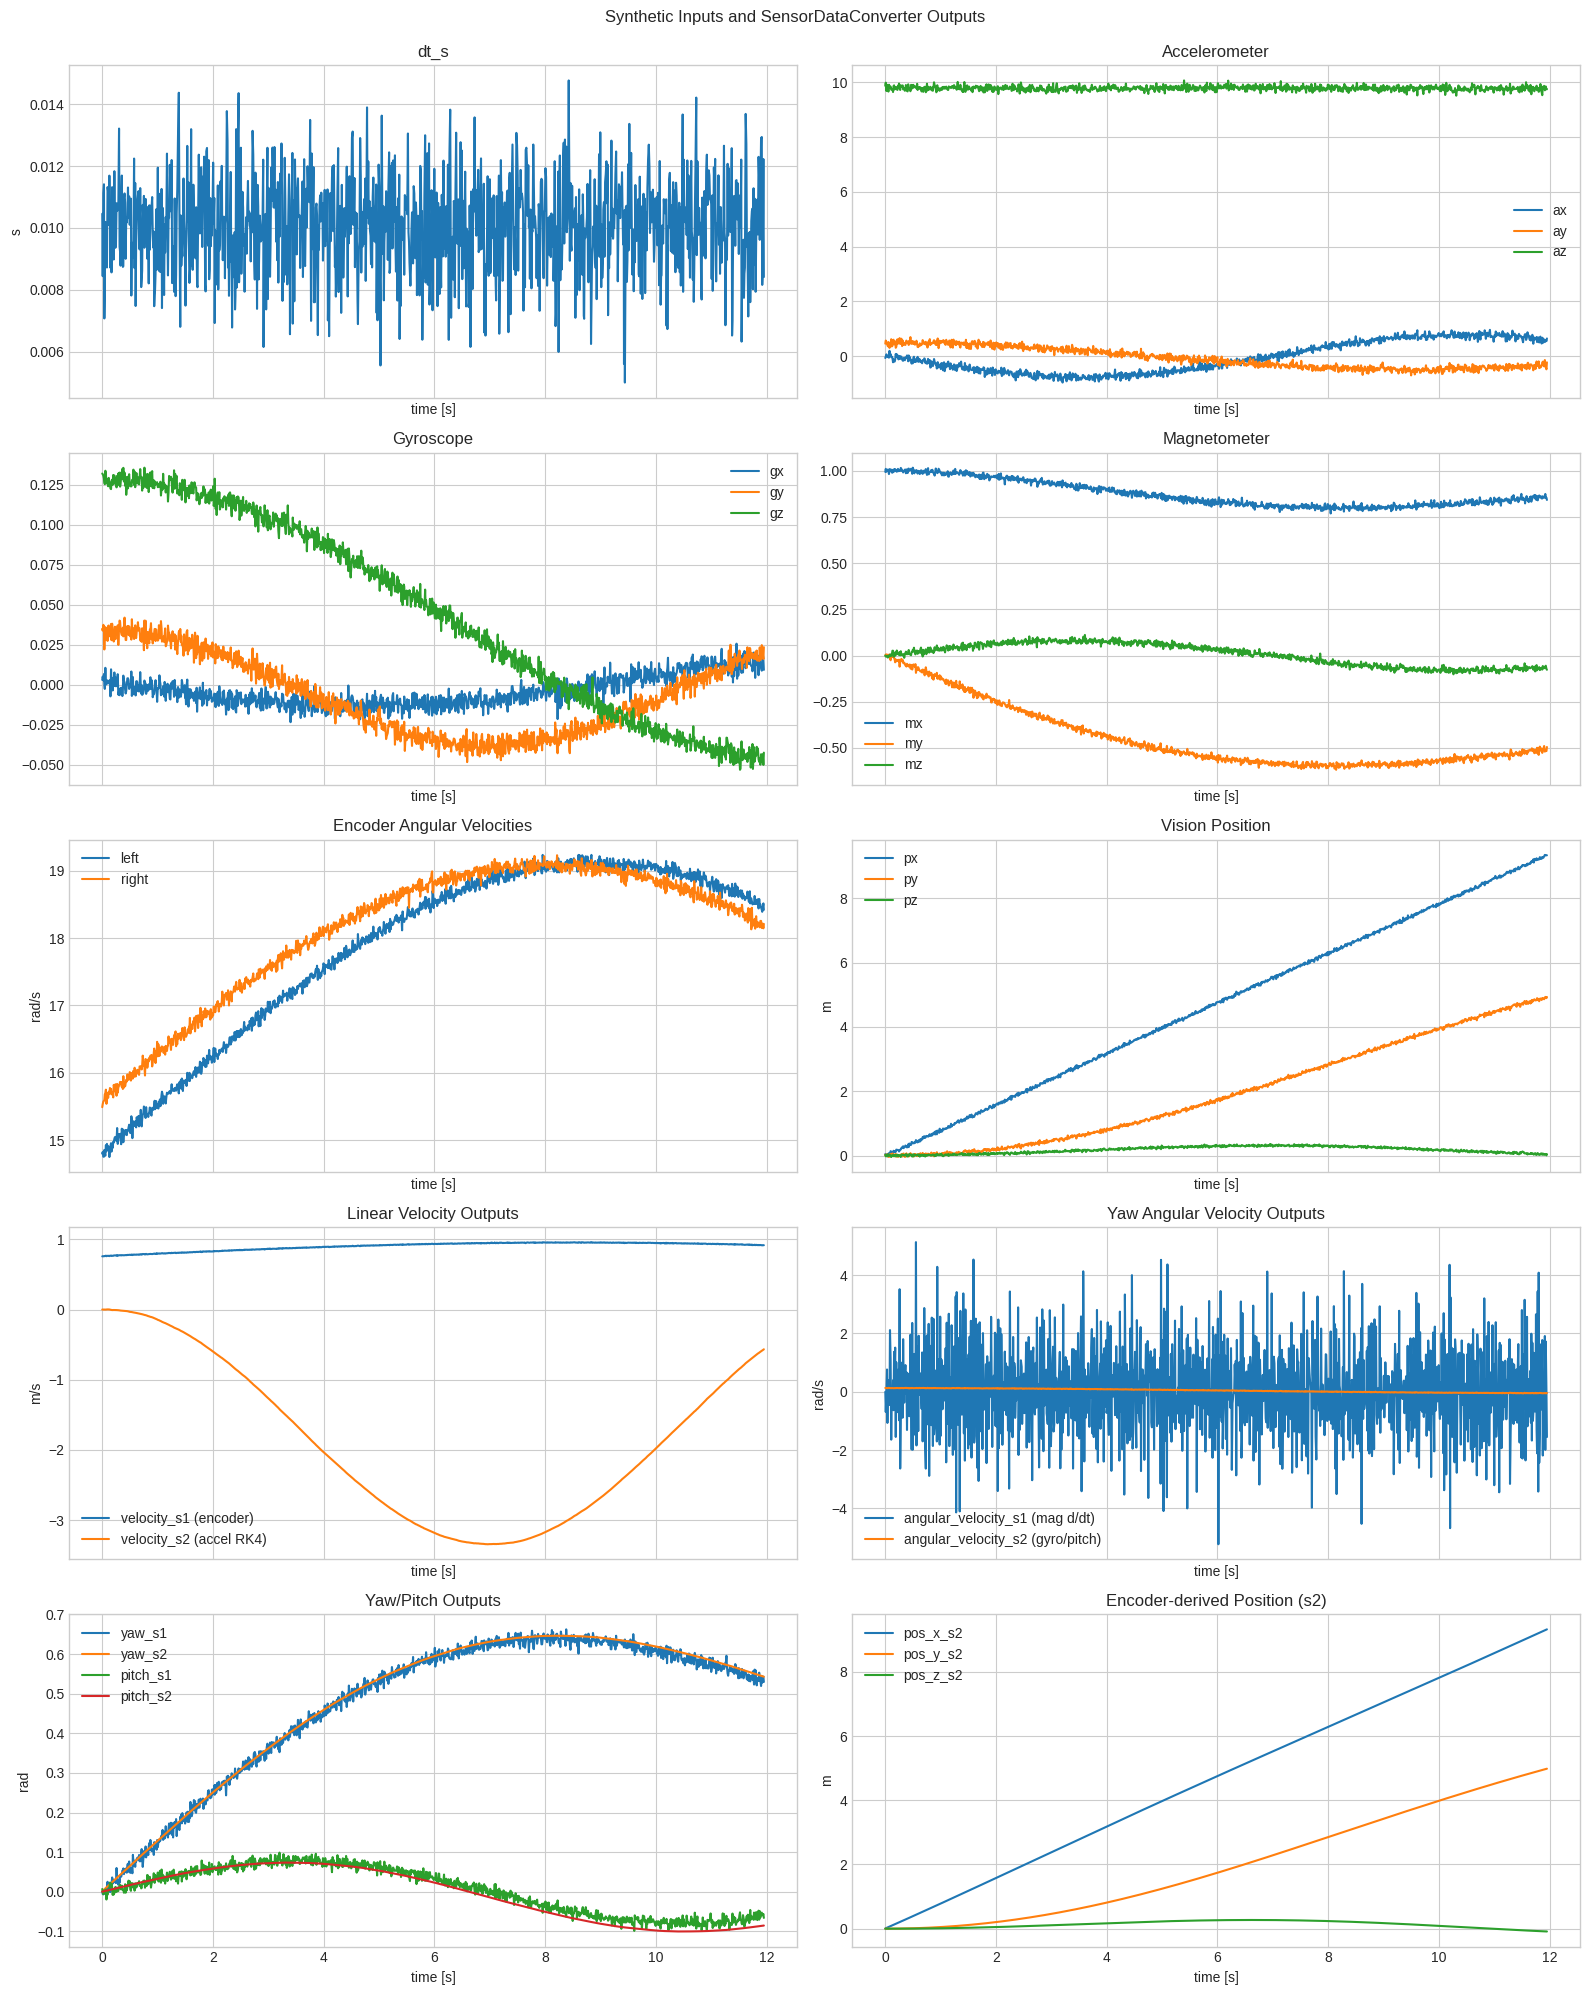

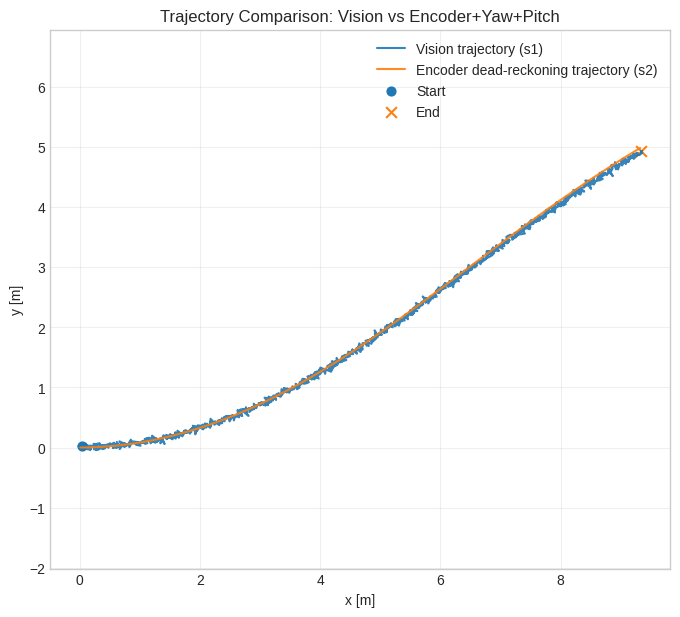

In [10]:
fig, axes = plt.subplots(5, 2, figsize=(16, 20), sharex=True)
axes = axes.ravel()

axes[0].plot(raw_df["t_s"], raw_df["dt_s"], color="tab:blue")
axes[0].set_title("dt_s")
axes[0].set_ylabel("s")

axes[1].plot(raw_df["t_s"], raw_df[["ax_mps2", "ay_mps2", "az_mps2"]])
axes[1].set_title("Accelerometer")
axes[1].legend(["ax", "ay", "az"], loc="best")

axes[2].plot(raw_df["t_s"], raw_df[["gx_radps", "gy_radps", "gz_radps"]])
axes[2].set_title("Gyroscope")
axes[2].legend(["gx", "gy", "gz"], loc="best")

axes[3].plot(raw_df["t_s"], raw_df[["mx", "my", "mz"]])
axes[3].set_title("Magnetometer")
axes[3].legend(["mx", "my", "mz"], loc="best")

axes[4].plot(raw_df["t_s"], raw_df[["encoder_left_radps", "encoder_right_radps"]])
axes[4].set_title("Encoder Angular Velocities")
axes[4].legend(["left", "right"], loc="best")
axes[4].set_ylabel("rad/s")

axes[5].plot(raw_df["t_s"], raw_df[["vision_px_m", "vision_py_m", "vision_pz_m"]])
axes[5].set_title("Vision Position")
axes[5].legend(["px", "py", "pz"], loc="best")
axes[5].set_ylabel("m")

axes[6].plot(raw_df["t_s"], converter_df[["velocity_s1", "velocity_s2"]])
axes[6].set_title("Linear Velocity Outputs")
axes[6].legend(["velocity_s1 (encoder)", "velocity_s2 (accel RK4)"], loc="best")
axes[6].set_ylabel("m/s")

axes[7].plot(raw_df["t_s"], converter_df[["angular_velocity_s1", "angular_velocity_s2"]])
axes[7].set_title("Yaw Angular Velocity Outputs")
axes[7].legend(["angular_velocity_s1 (mag d/dt)", "angular_velocity_s2 (gyro/pitch)"], loc="best")
axes[7].set_ylabel("rad/s")

axes[8].plot(raw_df["t_s"], converter_df[["yaw_s1", "yaw_s2", "pitch_s1", "pitch_s2"]])
axes[8].set_title("Yaw/Pitch Outputs")
axes[8].legend(["yaw_s1", "yaw_s2", "pitch_s1", "pitch_s2"], loc="best")
axes[8].set_ylabel("rad")

axes[9].plot(raw_df["t_s"], converter_df[["pos_x_s2", "pos_y_s2", "pos_z_s2"]])
axes[9].set_title("Encoder-derived Position (s2)")
axes[9].legend(["pos_x_s2", "pos_y_s2", "pos_z_s2"], loc="best")
axes[9].set_ylabel("m")

for ax in axes:
    ax.set_xlabel("time [s]")

fig.suptitle("Synthetic Inputs and SensorDataConverter Outputs", y=0.995)
fig.tight_layout()
plt.show()

plt.figure(figsize=(8, 7))
plt.plot(raw_df["vision_px_m"], raw_df["vision_py_m"], label="Vision trajectory (s1)", alpha=0.9)
plt.plot(converter_df["pos_x_s2"], converter_df["pos_y_s2"], label="Encoder dead-reckoning trajectory (s2)", alpha=0.9)
plt.scatter(raw_df["vision_px_m"].iloc[0], raw_df["vision_py_m"].iloc[0], marker="o", s=40, label="Start")
plt.scatter(raw_df["vision_px_m"].iloc[-1], raw_df["vision_py_m"].iloc[-1], marker="x", s=60, label="End")
plt.title("Trajectory Comparison: Vision vs Encoder+Yaw+Pitch")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.axis("equal")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.show()

## 11. Per-Sensor Comparison Against Ground Truth

Compare each sensor stream (`s1`, `s2`) against synthetic ground truth for all 7 states, and compute RMSE per sensor.

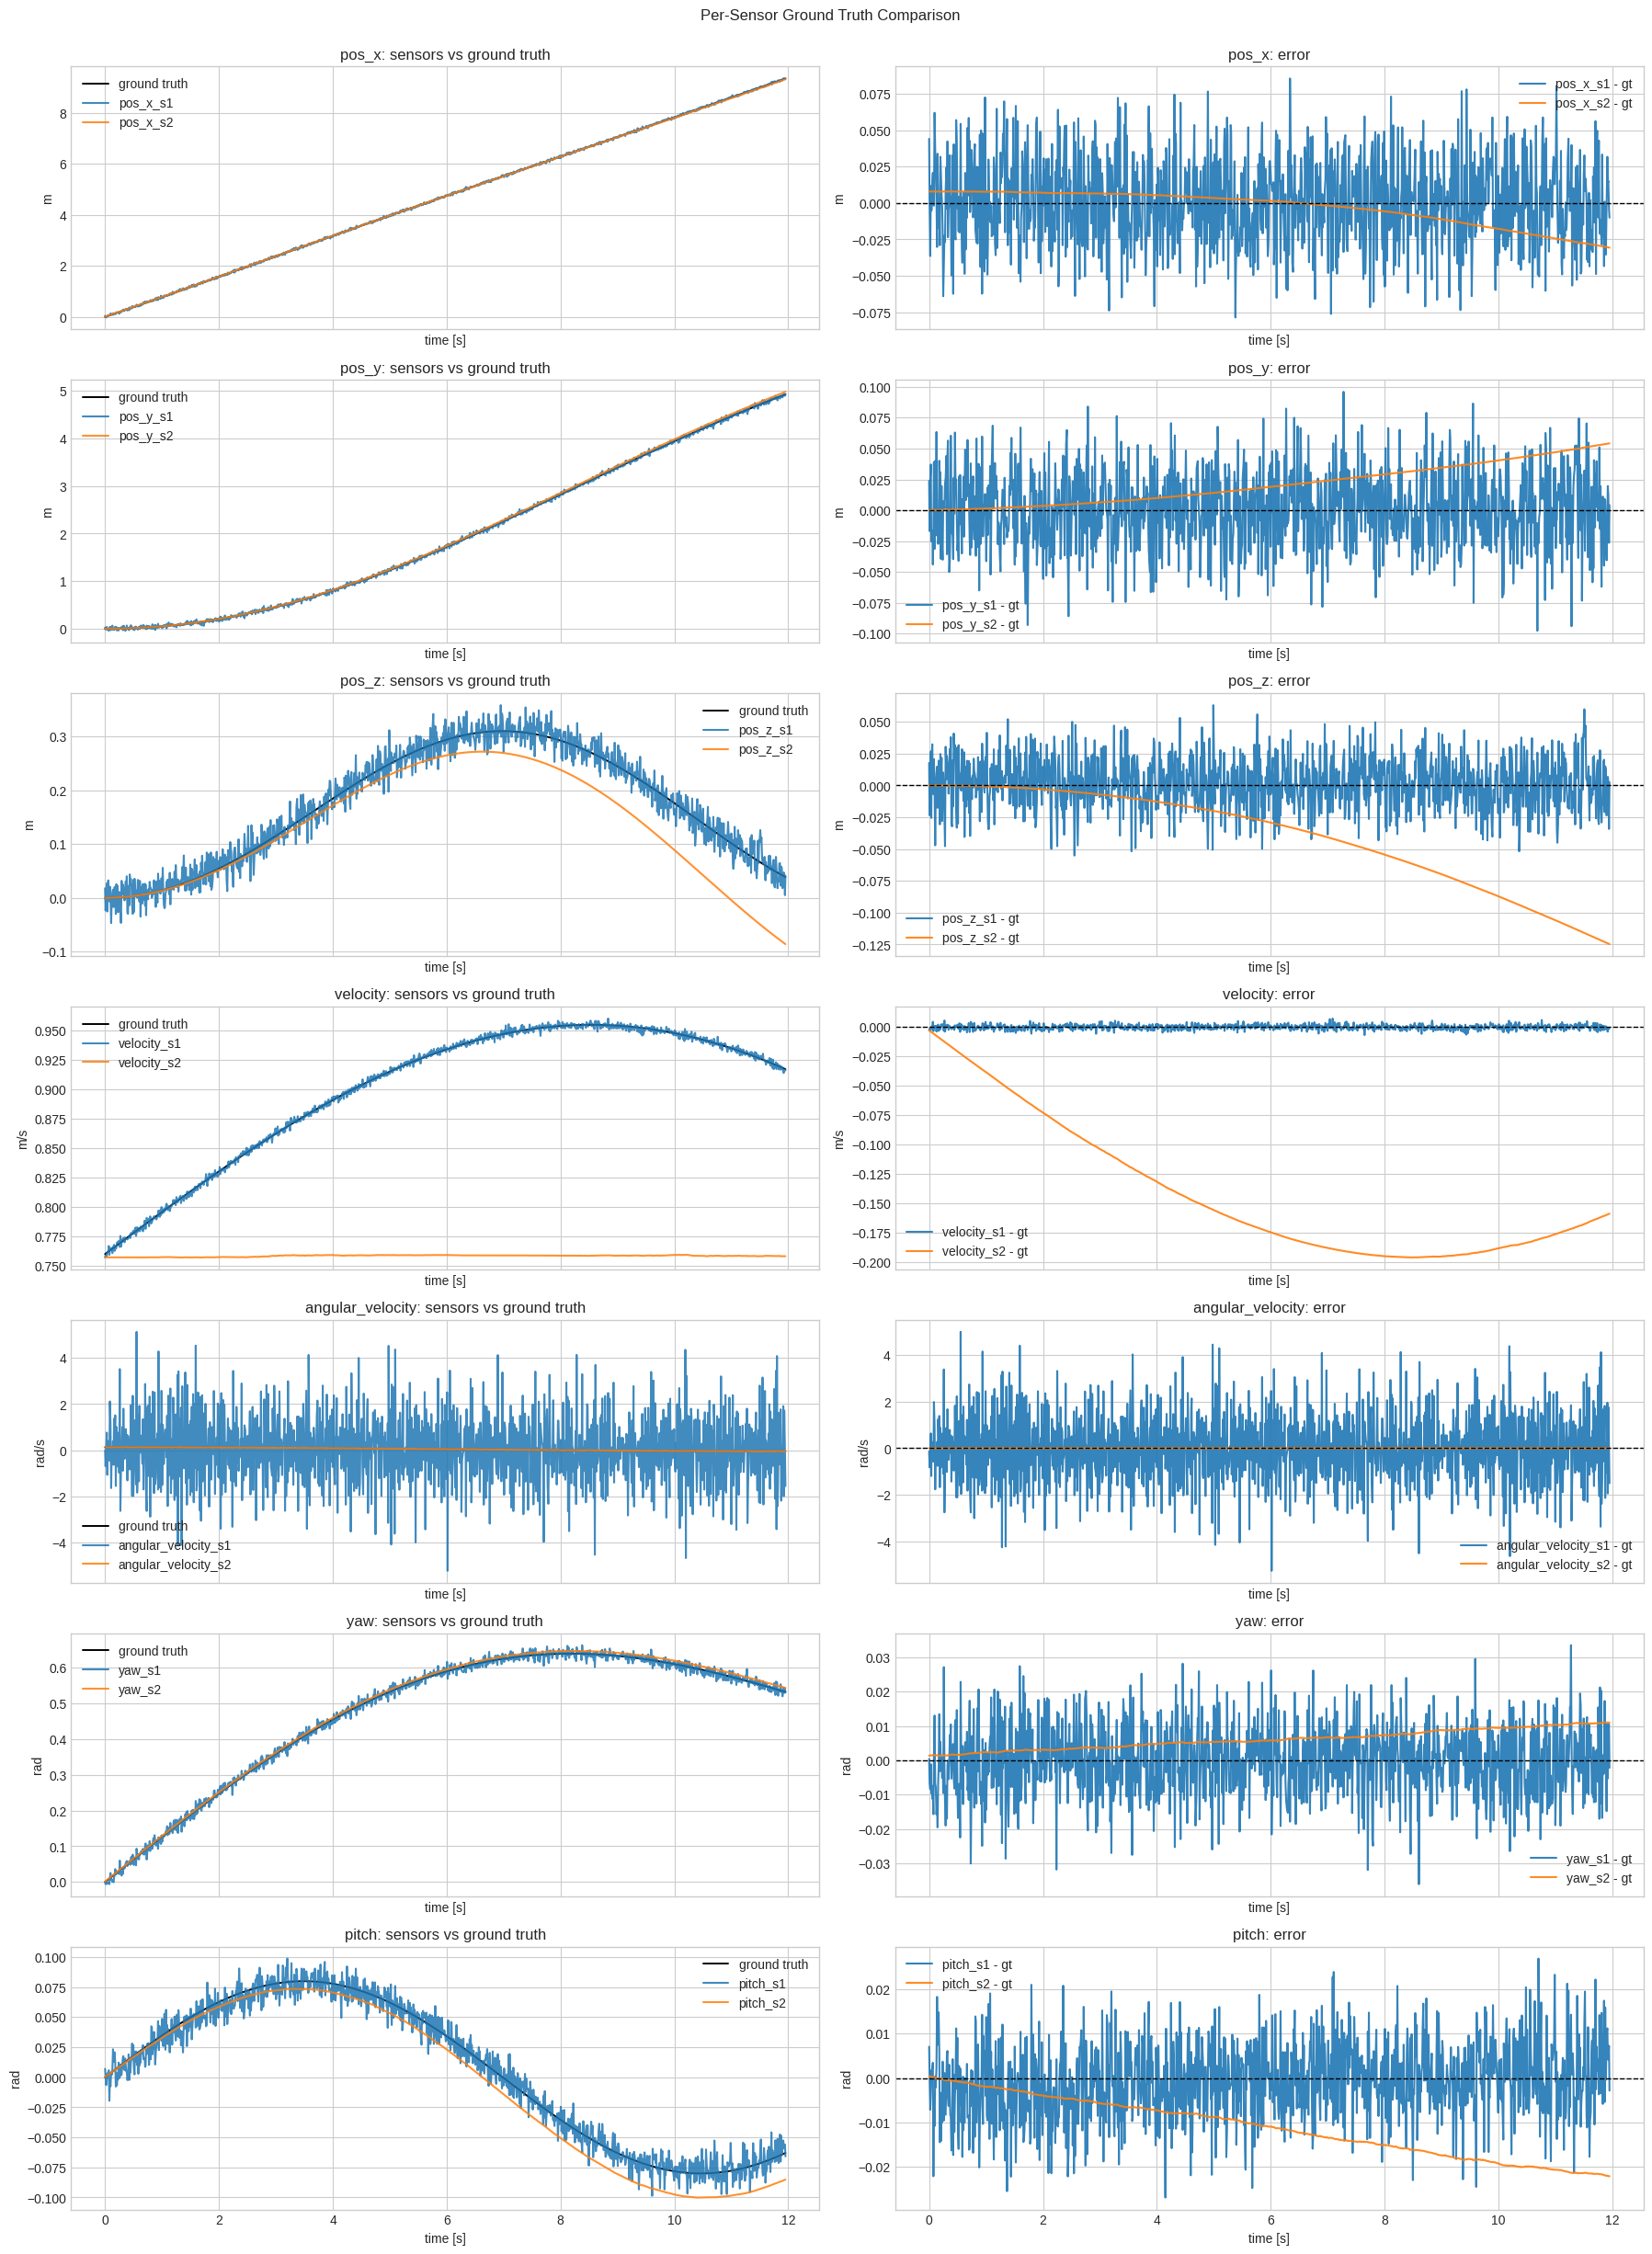

,state,rmse_s1,rmse_s2,better_sensor
0,pos_x,0.029450,0.011870,s2
1,pos_y,0.030345,0.026558,s2
2,pos_z,0.020039,0.055179,s1
3,velocity,0.002101,0.152851,s1
4,angular_velocity,1.492146,0.004038,s2
5,yaw,0.010237,0.006694,s2
6,pitch,0.008541,0.013034,s1


In [9]:
ground_truth_df = pd.DataFrame(
    {
        "pos_x_gt": px_true,
        "pos_y_gt": py_true,
        "pos_z_gt": pz_true,
        "velocity_gt": v_forward_true,
        "angular_velocity_gt": yaw_rate_true,
        "yaw_gt": yaw_true,
        "pitch_gt": pitch_true,
    }
)

comparison_map = [
    ("pos_x", "pos_x_s1", "pos_x_s2", "pos_x_gt", "m"),
    ("pos_y", "pos_y_s1", "pos_y_s2", "pos_y_gt", "m"),
    ("pos_z", "pos_z_s1", "pos_z_s2", "pos_z_gt", "m"),
    ("velocity", "velocity_s1", "velocity_s2", "velocity_gt", "m/s"),
    ("angular_velocity", "angular_velocity_s1", "angular_velocity_s2", "angular_velocity_gt", "rad/s"),
    ("yaw", "yaw_s1", "yaw_s2", "yaw_gt", "rad"),
    ("pitch", "pitch_s1", "pitch_s2", "pitch_gt", "rad"),
]

rmse_rows = []
fig_cmp, axes_cmp = plt.subplots(len(comparison_map), 2, figsize=(18, 3.5 * len(comparison_map)), sharex=True)

for i, (state_name, s1_col, s2_col, gt_col, unit) in enumerate(comparison_map):
    gt = ground_truth_df[gt_col]
    s1 = converter_df[s1_col]
    s2 = converter_df[s2_col]

    err_s1 = s1 - gt
    err_s2 = s2 - gt

    rmse_s1 = float(np.sqrt(np.mean(np.square(err_s1))))
    rmse_s2 = float(np.sqrt(np.mean(np.square(err_s2))))

    rmse_rows.append(
        {
            "state": state_name,
            "rmse_s1": rmse_s1,
            "rmse_s2": rmse_s2,
            "better_sensor": "s1" if rmse_s1 < rmse_s2 else "s2",
        }
    )

    ax_l = axes_cmp[i, 0]
    ax_l.plot(t_s, gt, label="ground truth", color="black", linewidth=1.4)
    ax_l.plot(t_s, s1, label=f"{s1_col}", alpha=0.85)
    ax_l.plot(t_s, s2, label=f"{s2_col}", alpha=0.85)
    ax_l.set_title(f"{state_name}: sensors vs ground truth")
    ax_l.set_ylabel(unit)
    ax_l.legend(loc="best")

    ax_r = axes_cmp[i, 1]
    ax_r.plot(t_s, err_s1, label=f"{s1_col} - gt", alpha=0.9)
    ax_r.plot(t_s, err_s2, label=f"{s2_col} - gt", alpha=0.9)
    ax_r.axhline(0.0, color="black", linewidth=1.0, linestyle="--")
    ax_r.set_title(f"{state_name}: error")
    ax_r.set_ylabel(unit)
    ax_r.legend(loc="best")

for ax in axes_cmp[:, 0]:
    ax.set_xlabel("time [s]")
for ax in axes_cmp[:, 1]:
    ax.set_xlabel("time [s]")

fig_cmp.suptitle("Per-Sensor Ground Truth Comparison", y=0.999)
fig_cmp.tight_layout()
plt.show()

rmse_df = pd.DataFrame(rmse_rows)
rmse_df